# Bank Customer Churn Prediction

### Project Overview

Customer churn is a major challenge for banks and subscription-based businesses.
The goal of this project is to predict whether a customer will leave the bank using historical customer data such as demographics, account details, and usage behavior.

We build and compare:

1. Logistic Regression

2. Random Forest Classifier

### Objective

1. Understand the dataset and target variable

2. Perform Exploratory Data Analysis (EDA)

3. Check class imbalance

4. Perform feature engineering

5. Train multiple models

6. Compare model performance using evaluation metrics

### Dataset Description

Dataset: Bank Customer Churn Dataset

Key Features:

CreditScore,
Geography,
Gender,
Age,
Tenure,
Balance,
NumOfProducts,
HasCrCard,
IsActiveMember,
EstimatedSalary,
RowNumber,
CustomerId,
Surname,

Target Variable:

Exited
1 → Customer churned
0 → Customer retained

## A. IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

## B. LOAD THE DATASET

In [2]:
df = pd.read_csv("D:\datasets\ml\Churn_Modelling.csv")

In [3]:
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


## C. BASIC DATA INSPECTION

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
df.shape

(10000, 14)

## D. DROPPING UNECESSARY COLUMNS

In [7]:
df.drop(['RowNumber', 'CustomerId', 'Surname'],axis=1,inplace=True)

In [8]:
df.head(10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


## E. TARGET VARIBLE DISTRIBUTION

In [9]:
# Count of churn vs non-churn
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

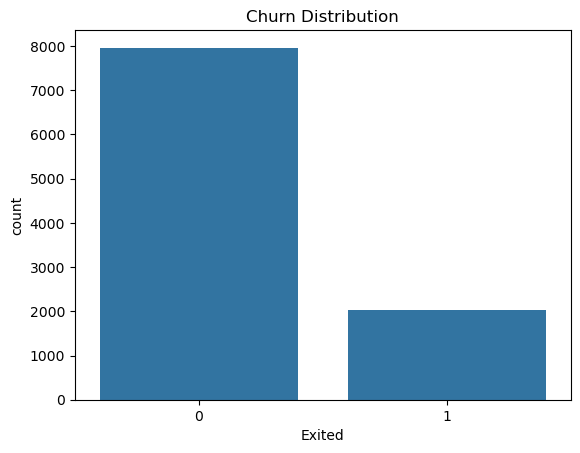

In [10]:
sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()

## F. ENCODING CATEGORICAL VALUES

In [11]:
# One-hot encoding
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_Germany  10000 non-null  bool   
 10  Geography_Spain    10000 non-null  bool   
 11  Gender_Male        10000 non-null  bool   
dtypes: bool(3), float64(2), int64(7)
memory usage: 732.6 KB


## G. DEFINING FEATURES

In [13]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [14]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [15]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

## H. TRAIN TEST SPLIT

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## I. FEATURE SCALING

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## J. TRAINING MODEL
### MODEL 1: LOGISTIC REGRESSION

In [18]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

### MODEL 2: RANDOM FOREST

In [19]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

## K. EVALUATE 
#### LOGISTIC REGRESSION

In [20]:
y_pred_log = log_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Accuracy: 0.808

Confusion Matrix:
 [[1540   53]
 [ 331   76]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [21]:
# ROC AUC
log_auc = roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1])
print("ROC AUC:", log_auc)

ROC AUC: 0.7747778595236223


#### RANDOM FOREST

In [22]:
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.8615

Confusion Matrix:
 [[1545   48]
 [ 229  178]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.79      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.74      2000
weighted avg       0.85      0.86      0.85      2000



In [23]:
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])
print("ROC AUC:", rf_auc)

ROC AUC: 0.8552797790085926


#### Model Performance Comparison Table

In [25]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Get classification reports as dict
log_report = classification_report(y_test, y_pred_log, output_dict=True)
rf_report  = classification_report(y_test, y_pred_rf, output_dict=True)

# Create comparison table
metrics_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    
    "Precision (Churn=1)": [
        log_report["1"]["precision"],
        rf_report["1"]["precision"]
    ],
    
    "Recall (Churn=1)": [
        log_report["1"]["recall"],
        rf_report["1"]["recall"]
    ],
    
    "F1-Score (Churn=1)": [
        log_report["1"]["f1-score"],
        rf_report["1"]["f1-score"]
    ],
    
    "ROC-AUC": [
        log_auc,
        rf_auc
    ]
})

metrics_table


,Model,Accuracy,Precision (Churn=1),Recall (Churn=1),F1-Score (Churn=1),ROC-AUC
0,Logistic Regression,0.8080,0.589147,0.186732,0.283582,0.774778
1,Random Forest,0.8615,0.787611,0.437346,0.562401,0.855280


Although Logistic Regression achieved reasonable accuracy, it failed to identify churned customers effectively. Random Forest showed superior performance with higher recall, F1-score, and ROC-AUC, making it the preferred model for churn prediction.

A comparative evaluation shows that Random Forest significantly outperforms Logistic Regression, especially in recall and F1-score for churned customers, making it a more suitable model for churn prediction.